<a href="https://colab.research.google.com/github/ml4devs/ml4devs-notebooks/blob/master/llm/running_llm_locally.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center>Running LLMs Locally Using llama.cpp & Ollama</center></h1>

<p><center>
<address>&copy; Satish Chandra Gupta<br/>
LinkedIn: <a href="https://www.linkedin.com/in/scgupta/">scgupta</a>,
Twitter: <a href="https://twitter.com/scgupta">scgupta</a>
</address>
</center></p>

---

Blog Post: [Run LLMs Locally: A Developer Setup Guide](https://www.ml4devs.com/articles/llm-local-inference-dev-setup/)

A hands-on notebook that runs local-LLM runtimes **live**:

| | Covers | Model used |
|---|---|---|
| **Setup** | Shared helpers used by every later cell. Run this first. | - |
| **Part 0** | Picking a model that fits your hardware (GPU VRAM or Mac unified memory). | - |
| **Part 1** | **llama.cpp**, the C/C++ engine most local tools are built on. GGUF and quantization. | Qwen2.5-3B, ~2 GB |
| **Part 2** | **Ollama**: scripted install, background server, OpenAI-compatible API. | Qwen2.5-3B, ~1.9 GB |
| **Part 3** | Text generation: summarizing, a timed coding task, streaming. | Qwen3.5-4B, ~3.4 GB |
| **Part 4** | Image understanding, through two different request formats. | Gemma 4 E4B, ~9.6 GB |
| **Appendix** | **LM Studio** (desktop GUI), and where the downloads live. | - |

**Runs on Google Colab and on a local 16 GB machine (macOS / Linux / Windows).** The heaviest download is Gemma 4 E4B at ~9.6 GB; everything else is under 4 GB. A full run pulls about **17 GB**: roughly 15 GB of Ollama models plus the ~2 GB GGUF file from Part 1. The last section shows where all of that lives and how to reclaim it.

Cells are **safe to re-run**: installs and model pulls are skipped when what they need is already present, and the server is started only if it is not already up. The one cell that changes state is at the end of Part 1: it unloads the llama.cpp model to free memory before Ollama starts, so re-run the model-loading cell before using Part 1 again.

> **Read model sizes, not model names.** "E4B" means ~4B *effective* parameters, but the file you download is ~9.6 GB. Part 0 explains why, along with the same trap for mixture-of-experts models. Always confirm with `ollama list`.

> **LM Studio note:** LM Studio is a desktop GUI app and cannot run in Colab's headless VM. A short appendix shows the client code you would run against it locally. Everything here speaks the OpenAI API format, so client code barely changes across runtimes.

> **Model tags:** names like `qwen3.5:4b` and `gemma4:e4b` reflect July 2026 releases. The notebook pulls them defensively and **falls back to a known model** if a tag is unavailable, so it still runs end to end. Check current tags at [ollama.com/library](https://ollama.com/library).

### Before You Start
- **On Colab:** for the fastest llama.cpp demo, enable a GPU via **Runtime -> Change runtime type -> Hardware accelerator -> GPU** (a free T4 is plenty). CPU works too, just slower.
- **On your own machine:** run the cells top to bottom. The llama.cpp backend (CUDA / Metal / CPU) and the per-OS Ollama install are auto-detected.
- **On Windows:** Ollama has no scripted install here. That cell prints a download link, and you re-run it once the installer has finished. Everything else is unchanged.


---

## Setup - Shared Helpers

Run this cell first. It defines the helpers every later cell uses, which is why the rest of the notebook stays short:

| Helper | What it does |
|---|---|
| `run_cmd` | Runs a command and echoes its output **into the cell**. Jupyter sends a subprocess's stdout to the terminal running the kernel, not to the notebook, which is how a failed installer looks like it worked. |
| `pip_install`, `ensure_import` | Install into *this* kernel's interpreter (`sys.executable`, correct even in local Jupyter), and import a module, installing it once if missing. |
| `require(name, hint)` | Read a variable an earlier cell set. If it is missing you get a message naming the cell to go back to, instead of a bare `NameError`. Notebooks get run out of order constantly. |
| `have`, `has_cuda` | Is a binary on `PATH`; is an NVIDIA GPU actually usable here. |
| `ollama_up`, `wait_for_ollama`, `ollama_models` | Server health check, startup wait bounded by wall-clock time, and the list of already-downloaded model tags. |
| `pull_model(tag, fallbacks)` | Download a model unless it is already present, and try the fallbacks if it fails. Returns the tag that actually works, or `None`. |

It also sets `OLLAMA_URL` to `http://127.0.0.1:11434`, the address every Ollama call in Parts 2 to 4 uses.

None of this is specific to LLMs. It is the plumbing that makes a notebook re-runnable and its failures readable.

In [1]:
# --- Shared helpers: run this cell first ---


import importlib
import os
import shutil
import subprocess
import sys
import time


def run_cmd(*cmd, shell=False, echo=True):
    """Run a command, capture its output, and echo it into THIS cell. Returns (ok, output).

    Always prefer this over a bare subprocess.run in a notebook. Jupyter does not fold a
    subprocess's stdout/stderr into the cell output: it goes to the terminal running the
    kernel, where you will never look. That is how an installer that printed a perfectly
    clear error message appears to "fail quietly".
    """
    try:
        proc = subprocess.run(cmd[0] if shell else list(cmd),
                              shell=shell, capture_output=True, text=True)
    except OSError as e:
        # The binary is not installed. Report it like any other failure rather than
        # raising, so a skipped install cell does not become a confusing traceback.
        out = f"{cmd[0]}: {e}"
        if echo:
            print(out)
        return False, out

    out = ((proc.stdout or "") + (proc.stderr or "")).strip()
    if echo:
        if out:
            print(out)
        if proc.returncode != 0:
            print(f"[FAILED] exit code {proc.returncode}")
    return proc.returncode == 0, out


def pip_install(*pkgs):
    """Install packages into THIS kernel's interpreter (correct even in local Jupyter).
    Returns True on success, printing pip's error so you get the real reason instead of a
    confusing ImportError several lines later."""
    ok, out = run_cmd(sys.executable, "-m", "pip", "install", "-q", *pkgs, echo=False)
    if not ok:
        print(f"[pip failed] {' '.join(pkgs)}")
        print(out[-1500:])
    return ok


def ensure_import(module, pip_name=None):
    "Import a module, installing it once if missing. Returns the module."
    try:
        return importlib.import_module(module)
    except ImportError:
        pip_install(pip_name or module)
        return importlib.import_module(module)


def require(name, hint):
    """Fail with a useful message instead of a bare NameError when cells are run out of order.
    Notebooks get run non-linearly all the time; this says which cell to go back to."""
    value = globals().get(name)
    if value is None:
        raise RuntimeError(f"`{name}` is not set. Run the cell that {hint} first.")
    return value


def have(binary):
    "True if an executable is on PATH."
    return shutil.which(binary) is not None


def has_cuda():
    "True only if an NVIDIA GPU is actually usable."
    return have("nvidia-smi") and run_cmd("nvidia-smi", echo=False)[0]


requests = ensure_import("requests")
os.environ.setdefault("OLLAMA_HOST", "127.0.0.1:11434")
OLLAMA_URL = "http://127.0.0.1:11434"


def ollama_up():
    "True if the Ollama server responds."
    try:
        return requests.get(f"{OLLAMA_URL}/api/version", timeout=2).ok
    except Exception:
        return False


def wait_for_ollama(seconds=60):
    """Poll until the server answers, giving up after `seconds` of WALL CLOCK time.
    (Counting loop iterations would not do that: each iteration also spends up to 2s
    inside the request timeout, so 60 iterations could mean 3 minutes.)"""
    deadline = time.time() + seconds
    while time.time() < deadline:
        if ollama_up():
            return True
        time.sleep(1)
    return False


def ollama_models():
    "List already-downloaded model tags (empty list if server is down)."
    try:
        data = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5).json()
        return [m.get("name", "") for m in data.get("models", [])]
    except Exception:
        return []


def _canonical(tag):
    "Ollama reports an untagged name as ':latest'. Normalize before comparing."
    return tag if ":" in tag else f"{tag}:latest"


def pull_model(tag, fallbacks=()):
    """Ensure a model is available. Skip if already present; on failure try fallbacks.
    Returns a usable tag, or None if nothing worked."""

    present = {_canonical(n) for n in ollama_models()}
    for t in (tag, *fallbacks):
        # Match the FULL tag, not just the family name. qwen3.5:9b and qwen3.5:4b are
        # separate downloads, so treating one as proof of the other would report
        # "already available" and then 404 on the first chat call.
        if _canonical(t) in present:
            print(f"[ok]   {t} already available")
            return t
        print(f"[pull] {t} ... (large download, no progress bar: Jupyter hides subprocess output)")
        ok, out = run_cmd("ollama", "pull", t, echo=False)
        if ok:
            return t
        print(f"[warn] could not pull {t}:")
        print(out[-800:] or "  (no output)")
    print(f"[ERROR] none of {(tag, *fallbacks)} could be pulled. See https://ollama.com/library")
    return None


print("Helpers ready.")

Helpers ready.


---

## Part 0 - Choosing the Right Model for Your Hardware

The single biggest constraint is memory. A model needs roughly **0.5 GB per billion parameters at 4-bit (Q4)**, plus 15-20% for the KV cache and overhead at short context lengths. Long contexts push the KV cache much higher, so treat `n_ctx` as a memory knob, not just a quality knob. On a GPU that memory is VRAM; on Apple Silicon it is **unified memory shared with macOS and your apps**, so reserve ~5-6 GB for the system.

**Two traps that break the arithmetic:**

- **Count total parameters, not active ones.** Mixture-of-experts (MoE) models advertise a small "active" count, which is a *speed* figure. All the weights still have to be resident. Llama 4 Scout is "17B active" but 109B total, so it needs roughly 55-60 GB at Q4, not 9 GB.
- **Count the download, not the name.** Gemma 4 **E4B** means ~4B *effective* parameters, achieved by a technique that still ships far more weights. The actual Ollama download is **~9.6 GB**, not ~3 GB. After pulling anything, check the real number with `ollama list`.

Sizes below are measured download sizes where the notebook pulls the model.

### Desktop / laptop with an NVIDIA GPU (by VRAM)

| VRAM | Recommended | Also good |
|---|---|---|
| **8 GB** | Qwen3.5-9B (Q4, ~6.6 GB) fits, but leaves little room for context | Qwen3.5-4B (~3.4 GB) for long prompts, Qwen2.5-Coder 7B (code), Phi-4 Mini (reasoning), `llava` (vision, ~4.7 GB) |
| **12-16 GB** | Gemma 4 12B (Q4) | Qwen3.5-9B for headroom, **Gemma 4 E4B** (vision, ~9.6 GB) |
| **24 GB** (RTX 4090/3090) | **Qwen3.6-27B** (Q4, ~17 GB) | Gemma 4 31B |
| **40 GB+** | Qwen3.6-27B (Q8 / long context) or GLM-5.2 | higher precision or long context; 70B+ dense models and large MoE models such as Llama 4 Scout need this tier or multi-GPU |

### MacBook / Mac (by unified memory)

| Memory | Recommended | Notes |
|---|---|---|
| **16 GB Air** | **Qwen3.5-9B** (~6.6 GB) | Stay <=9B. **Qwen3.5-4B** (~3.4 GB) when you want lighter and faster; Gemma 4 E4B (~9.6 GB) fits, but only just |
| **24 GB Air** | Qwen3.5-9B / Qwen3-14B | Qwen3.5-27B only for short, high-value prompts (fanless throttle) |
| **32-36 GB** | Qwen3.6-27B / Gemma 4 26B | Frontier reasoning locally |
| **48 GB+** | Qwen3.6-27B / Gemma 4 31B | Comfortable headroom |

**Mac tips:** prefer **MLX** builds (LM Studio's MLX backend or `mlx-lm`); they run ~10-20% faster than llama.cpp. Note that Ollama itself only uses MLX on **32 GB+** Macs; on a 16 or 24 GB Mac it runs on Metal, so use LM Studio's MLX runtime or `mlx-lm` to get MLX there. The fanless Air throttles after ~20-30 min of continuous inference, so treat big models as a tool for short bursts.

The cell below reads this machine's RAM, CPU architecture, and (via `nvidia-smi`) GPU VRAM, then prints a recommendation from the same thresholds as the tables above. It has four paths: Apple Silicon, Intel Mac (CPU inference, with neither unified memory nor MLX), an NVIDIA GPU with 8 GB or more, and everything else, which means small models on CPU.

In [2]:
# Detect this machine and recommend a model.
# These thresholds mirror the tables above; keep the two in sync if you edit either.


import platform
import subprocess


psutil = ensure_import("psutil")


system = platform.system()
machine = platform.machine()
ram_gb = psutil.virtual_memory().total / (1024 ** 3)

# "Darwin" alone is not enough: Intel Macs have neither unified memory nor MLX,
# so they belong on the CPU path, not the Apple Silicon one.
is_apple_silicon = system == "Darwin" and machine in ("arm64", "aarch64")


vram_gb = 0.0
if have("nvidia-smi"):
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=memory.total", "--format=csv,noheader,nounits"],
            stderr=subprocess.DEVNULL).decode().split()
        vram_gb = max(int(x) for x in out if x.isdigit()) / 1024
    except Exception:
        pass


def gpu_pick(v):
    if v >= 40: return "Qwen3.6-27B (Q8 / long context) or GLM-5.2 - higher precision; 70B+ dense and large MoE need multi-GPU"
    if v >= 24: return "Qwen3.6-27B (Q4, ~17 GB) - top desktop pick"
    if v >= 12: return "Gemma 4 12B (Q4) or Qwen3.5-9B (~6.6 GB); Gemma 4 E4B (~9.6 GB) for vision"
    if v >= 8:  return "Qwen3.5-9B (Q4, ~6.6 GB) - fits but tight; Qwen3.5-4B (~3.4 GB) for long prompts"
    return "Qwen3.5-4B (~3.4 GB) or smaller"


def mac_pick(r):
    if r >= 48: return "Qwen3.6-27B / Gemma 4 31B (Q4)"
    if r >= 32: return "Qwen3.6-27B (Q4, ~16 GB) or Gemma 4 26B"
    if r >= 24: return "Qwen3.5-9B / Qwen3-14B daily; Qwen3.5-27B for short prompts"
    if r >= 16: return "Qwen3.5-9B (Q4, ~6.6 GB); Qwen3.5-4B (~3.4 GB) when lighter"
    return "Qwen3.5-4B (~3.4 GB) or smaller"


print(f"OS: {system} ({machine}) | Python: {platform.python_version()} "
      f"| RAM: {ram_gb:.0f} GB | GPU VRAM: {vram_gb:.0f} GB\n")

if is_apple_silicon:
    print("Apple Silicon (unified memory).")
    print("  Recommended:", mac_pick(ram_gb))
    print("  Tip: prefer MLX builds; the fanless Air throttles after ~20-30 min.")
elif system == "Darwin":
    print("Intel Mac -> CPU inference. No unified memory, and MLX is Apple Silicon only.")
    print("  Recommended: Qwen3.5-4B (~3.4 GB) or smaller (expect slower tok/s).")
elif vram_gb >= 8:
    print("NVIDIA GPU detected.")
    print("  Recommended:", gpu_pick(vram_gb))
else:
    print("No usable GPU detected -> small models on CPU.")
    print("  Recommended: Qwen3.5-4B (~3.4 GB) or smaller (expect slower tok/s).")

OS: Linux (x86_64) | Python: 3.12.13 | RAM: 13 GB | GPU VRAM: 15 GB

NVIDIA GPU detected.
  Recommended: Gemma 4 12B (Q4) or Qwen3.5-9B (~6.6 GB); Gemma 4 E4B (~9.6 GB) for vision


---

## Part 1 - llama.cpp

**llama.cpp is the engine.** Ollama (Part 2) and LM Studio (appendix) are both front ends built on
top of it. So this notebook is not three different ways to run a model, it is one inference engine
wrapped at three levels of convenience:

| | What it actually is | What you write |
|---|---|---|
| **llama.cpp** | the C/C++ inference engine | Python against a model object |
| **Ollama** | engine + model manager + HTTP server | OpenAI API calls |
| **LM Studio** | all of the above + a desktop GUI | OpenAI API calls |

That relationship is worth internalizing early: when a model runs slowly under Ollama, the fix is
almost always a llama.cpp-level knob (quantization, context length, GPU offload), not an Ollama
setting.

The cells below walk the full path from nothing installed to a measured tokens/sec number. On a
16 GB machine the 3B demo model needs only ~2 GB.

1. **Install `llama-cpp-python`** from the maintainer's **prebuilt wheels only**, never a source build. The cell picks a backend (a specific CUDA version, Metal, or CPU), then **verifies it by importing it in a separate process** before keeping it. That check matters: those wheels carry no CUDA version in their filename, so pip will install a CUDA 13 build on a CUDA 12 machine and report success, and you find out at import time. A successful `pip install` is not the same as a working library. If no wheel loads, `LLAMA_CPP_OK` stays `False` and Part 1 skips itself; nothing later in the notebook depends on it.
2. **Decide how many layers go on the GPU.** The question is put to the installed library (`llama_supports_gpu_offload()`), not to the hardware, because those are different questions: a CPU-only wheel on a machine with an RTX 4090 must still use 0 GPU layers. `n_gpu_layers=-1` offloads every layer, `0` is CPU-only, and a partial number splits a model that is slightly too big for your VRAM.
3. **Download a quantized GGUF** from Hugging Face (~2 GB, cached after the first run). The next markdown cell unpacks what "GGUF" and "Q4_K_M" mean.
4. **Load the model and run a chat completion.** `create_chat_completion` takes the same `messages` list you know from the OpenAI API, so the mental model carries over.
5. **Measure tokens/sec**, after an untimed warm-up call. Part 3 repeats this measurement through Ollama so the two are comparable.

A final cell then deletes the model object to hand its memory back before Ollama starts, so the two
runtimes never compete for the same VRAM.

In [3]:
# Install llama-cpp-python from FIRST-PARTY PREBUILT WHEELS ONLY - never compiles.
# --only-binary=:all: guarantees pip will not fall back to a source build.
#
# Two things make this fiddlier than a normal pip install:
#
# 1. PyPI publishes ONLY a source tarball for llama-cpp-python, so a bare
#    "pip install --only-binary=:all: llama-cpp-python" finds nothing at all. Every
#    prebuilt wheel (CPU, Metal, CUDA) lives in the maintainer's index below.
#
# 2. Those wheels are tagged "py3-none-<platform>", which says NOTHING about CUDA. pip will
#    happily install a CUDA 13 build onto a CUDA 12 machine and report success. The failure
#    surfaces much later, at import time:
#        RuntimeError: Failed to load shared library '.../libllama.so':
#        libcudart.so.13: cannot open shared object file
#    So: pick the tag from what this machine can actually load, then VERIFY by importing
#    the result before accepting it. "pip succeeded" is not the same as "it works."


import ctypes
import importlib.util
import platform
import sys


WHEEL_INDEX = "https://abetlen.github.io/llama-cpp-python/whl"
# Published by the maintainer, newest first. cu132 -> CUDA 13.2 -> links libcudart.so.13
CUDA_TAGS = ["cu132", "cu130", "cu125", "cu124", "cu123", "cu122", "cu121", "cu118"]


def _tag_major(tag):
    "cu132 -> 13, cu124 -> 12, cu118 -> 11"
    return int(tag[2:]) // 10


def _loadable_cudart_majors():
    """CUDA runtime major versions the dynamic loader can actually find here.

    This is the ground truth, and it is NOT what nvidia-smi reports. The "CUDA Version"
    in nvidia-smi output is the highest release the DRIVER supports, not the runtime that
    is installed. A driver advertising 13.x on a machine that only ships libcudart.so.12
    is completely normal, and trusting that number is exactly how you end up with a cu132
    wheel that cannot load.

    If ctypes cannot dlopen the library, neither can libllama.so: same loader, same rules.
    """
    found = []
    for major in (13, 12, 11):
        try:
            ctypes.CDLL(f"libcudart.so.{major}")
            found.append(major)
        except OSError:
            continue
    return found


def _cuda_candidates(limit=3):
    "A short, ordered list of CUDA tags worth trying on this machine."
    majors = _loadable_cudart_majors()
    ranked = [t for t in CUDA_TAGS if _tag_major(t) in majors]
    if ranked:
        print(f"Detected CUDA runtime major version(s): {majors}")
        return ranked[:limit]
    # Some environments keep cudart off the default loader path, so an empty probe is not
    # proof of absence. Try the newest few; the import check below rejects what fails.
    print("Could not probe the CUDA runtime; trying the newest wheels and verifying each.")
    return CUDA_TAGS[:limit]


def _pip_wheel_only(backend):
    "pip install from the prebuilt-wheel index for `backend`. Returns True on success."
    ok, out = run_cmd(sys.executable, "-m", "pip", "install", "-q", "--only-binary=:all:",
                      "--extra-index-url", f"{WHEEL_INDEX}/{backend}", "llama-cpp-python",
                      echo=False)
    if not ok and out:
        print(f"  pip said: {out.strip().splitlines()[-1][:200]}")
    return ok


def _pip_uninstall():
    run_cmd(sys.executable, "-m", "pip", "uninstall", "-y", "-q", "llama-cpp-python",
            echo=False)


def _import_works():
    """Import llama_cpp in a FRESH process and touch the native library.

    A subprocess matters here: a half-broken native extension can leave this kernel in a
    state where retrying needs a restart. Testing out-of-process keeps failures disposable.
    """
    probe = "import llama_cpp; llama_cpp.llama_supports_gpu_offload()"
    return run_cmd(sys.executable, "-c", probe, echo=False)[0]


def _try_backend(backend):
    "Install one backend and keep it only if it actually imports."
    print(f"Trying prebuilt wheel: {backend} ...")
    if not _pip_wheel_only(backend):
        print(f"[warn] no {backend} wheel for this platform.")
        return False
    if _import_works():
        print(f"Installed and verified: {backend}")
        return True
    print(f"[warn] the {backend} wheel installed but will not load here; removing it.")
    _pip_uninstall()   # must remove it, or pip treats the requirement as already satisfied
    return False


def install_llama_cpp():
    # An existing install still has to be checked: a broken CUDA build from an earlier run
    # looks perfectly "installed" to find_spec and only fails when you import it.
    if importlib.util.find_spec("llama_cpp") is not None:
        if _import_works():
            print("llama-cpp-python already installed and loadable; skipping.")
            return True
        print("llama-cpp-python is installed but fails to load; reinstalling.")
        _pip_uninstall()

    if has_cuda():
        for tag in _cuda_candidates():
            if _try_backend(tag):
                return True
        print("No CUDA wheel loaded here; falling back to CPU (slower, but it works).")
    elif platform.system() == "Darwin":
        if _try_backend("metal"):
            return True
        print("No Metal wheel; falling back to CPU.")

    if _try_backend("cpu"):
        return True

    print("[WARN] No prebuilt wheel works on this platform. This notebook does NOT build")
    print("       from source by design - skip Part 1 and use the Ollama sections below,")
    print("       which have no such constraint.")
    return False


LLAMA_CPP_OK = install_llama_cpp()
ensure_import("huggingface_hub")

Detected CUDA runtime major version(s): [12]
Trying prebuilt wheel: cu125 ...
Installed and verified: cu125


<module 'huggingface_hub' from '/usr/local/lib/python3.12/dist-packages/huggingface_hub/__init__.py'>

In [4]:
# How many layers can we push onto the GPU?
#
# Ask the INSTALLED library, not the hardware. Those are different questions: a CPU-only
# wheel on a machine with an RTX 4090 must still use 0 GPU layers, and guessing from
# nvidia-smi would produce a model that fails to load.

N_GPU_LAYERS = 0

if not globals().get("LLAMA_CPP_OK"):
    print("llama-cpp-python is not usable here, so Part 1 will be skipped.")
    print("Re-run the install cell above; if it still fails, go straight to Part 2 (Ollama).")
    print("Nothing after Part 1 depends on it.")
else:
    import llama_cpp
    if llama_cpp.llama_supports_gpu_offload():
        N_GPU_LAYERS = -1  # -1 = offload every layer

    print("GPU offload available:", N_GPU_LAYERS == -1, "| n_gpu_layers:", N_GPU_LAYERS)
    print("(-1 offloads all layers; 0 is CPU-only. A partial number like 20 splits the model,")
    print(" which is how you run a model slightly too big for your VRAM.)")

ggml_cuda_init: found 1 CUDA devices (Total VRAM: 14912 MiB):
  Device 0: Tesla T4, compute capability 7.5, VMM: yes, VRAM: 14912 MiB


GPU offload available: True | n_gpu_layers: -1
(-1 offloads all layers; 0 is CPU-only. A partial number like 20 splits the model,
 which is how you run a model slightly too big for your VRAM.)


### What Is GGUF, and What Does "Q4_K_M" Mean?

The file being downloaded is `Qwen2.5-3B-Instruct-Q4_K_M.gguf`. Two ideas are packed into that name,
and both come up constantly once you start running models locally.

**GGUF** is llama.cpp's model format: weights, tokenizer, and metadata in a single file that can be
memory-mapped straight off disk. That is why local runtimes start quickly, and why one download
works unchanged across CPU, CUDA, and Metal.

**Q4_K_M** describes the quantization, read left to right:

| Piece | Meaning |
|---|---|
| `Q4` | weights stored at roughly 4 bits each, down from 16 |
| `_K` | "K-quant": a smarter scheme that spends more bits on the layers that are most sensitive to rounding |
| `_M` | the medium size within that family (`_S` is smaller and worse, `_L` larger and better) |

**Which to pick.** `Q4_K_M` is the sensible default: about a 4x size reduction for a quality loss
most people cannot detect in normal use. Two rules of thumb worth remembering:

- Below Q4 (Q3, Q2) quality falls off quickly. That is usually the signal to move to a *smaller model* rather than a more aggressive quantization of a big one.
- **For a fixed memory budget, a bigger model at Q4 usually beats a smaller model at Q8.** Spend your bytes on parameters before precision.

The repository here (`bartowski/Qwen2.5-3B-Instruct-GGUF`) is a community quantizer's, which is the
normal way to get GGUF builds: the original model publishers usually ship full-precision weights,
and quantized GGUF files are converted and uploaded by others.

In [5]:
# Download a 4-bit GGUF of Qwen2.5-3B-Instruct (~2 GB, open / ungated). Cached after first run.

from huggingface_hub import hf_hub_download


model_path = None
try:
    model_path = hf_hub_download(
        repo_id="bartowski/Qwen2.5-3B-Instruct-GGUF",
        filename="Qwen2.5-3B-Instruct-Q4_K_M.gguf",
    )
    print("Model file:", model_path)
except Exception as e:
    print("[ERROR] download failed:", e)
    print("Check your network / Hugging Face availability, then re-run this cell.")

Qwen2.5-3B-Instruct-Q4_K_M.gguf: reconstructing file:   0%|          |  0.00B / 1.93GB            

Qwen2.5-3B-Instruct-Q4_K_M.gguf: downloading bytes:           |  0.00B            

Model file: /root/.cache/huggingface/hub/models--bartowski--Qwen2.5-3B-Instruct-GGUF/snapshots/f302c64a2269a69fb27b2f9473b362f5bb8e78d8/Qwen2.5-3B-Instruct-Q4_K_M.gguf


In [6]:
# Load the model (GPU offload if available, else CPU) and run a chat completion. Safe to re-run.

if not globals().get("LLAMA_CPP_OK"):
    raise RuntimeError(
        "llama-cpp-python is not usable on this machine, so Part 1 cannot run. "
        "Re-run the install cell above, or skip to Part 2 (Ollama) - nothing later depends on it."
    )

from llama_cpp import Llama


model_path = require("model_path", "downloads the GGUF file")
n_layers = require("N_GPU_LAYERS", "checks GPU offload support")

# n_ctx is a memory knob as well as a quality one: the KV cache grows with it.
llm = Llama(model_path=model_path, n_gpu_layers=n_layers, n_ctx=4096, verbose=False)

out = llm.create_chat_completion(
    messages=[
        {"role": "system", "content": "You are a concise, helpful assistant."},
        {"role": "user", "content": "In 3 bullets, explain what quantization does for local LLMs."},
    ],
    max_tokens=256,
)
print(out["choices"][0]["message"]["content"])

1. Quantization reduces the precision of model weights, significantly decreasing model size and computational requirements.
2. It enables local LLMs to run on devices with limited resources, such as mobile phones or edge devices.
3. Quantization speeds up inference time by reducing the number of operations needed, improving latency and performance.


In [7]:
# Throughput check (tokens/sec).
#
# Part 3 runs the SAME measurement through Ollama so the two are directly comparable.
# Both warm up first and both report tok/s rather than wall-clock seconds, because
# wall clock mostly measures how long the answer happened to be.

import time


llm = require("llm", "loads the Llama model")
n_layers = require("N_GPU_LAYERS", "checks GPU offload support")

# Warm-up: absorbs one-off setup cost. Not timed.
llm.create_chat_completion(messages=[{"role": "user", "content": "ping"}], max_tokens=1)

t0 = time.time()
out = llm.create_chat_completion(
    messages=[{"role": "user",
               "content": "Write a haiku about running models locally, "
                          "then explain the imagery in two sentences."}],
    max_tokens=128,
)
dt = time.time() - t0

n = out["usage"]["completion_tokens"]
print(out["choices"][0]["message"]["content"])
print(f"\nllama.cpp: {n} completion tokens in {dt:.2f}s -> {n / dt:.1f} tok/s")
print(f"(n_gpu_layers={n_layers}; 0 means CPU-only, which is typically several times slower)")

Running models locally,
Cold CPU hums with silent might,
Weights settle in air.

In this haiku, the first line evokes the quiet, mechanical process of running machine learning models locally, with the "CPU hums" symbolizing the computational effort. The second line personifies the CPU as a living entity, with its "silent might" suggesting the power and efficiency of the local processing. The third line shifts focus to the model's weights, which "settle in air" as if they are particles in a vacuum, symbolizing the model's readiness and the absence of external dependencies.

llama.cpp: 120 completion tokens in 1.73s -> 69.5 tok/s
(n_gpu_layers=-1; 0 means CPU-only, which is typically several times slower)


In [8]:
# Free memory before starting Ollama so the two don't compete for VRAM.
#
# This UNLOADS the llama.cpp model on purpose. To run the Part 1 chat or throughput cells
# again afterwards, re-run the "Load the model" cell first. (You will not get a cryptic
# NameError if you forget: `require` says which cell to go back to.)

import gc


if globals().get("llm") is not None:
    del llm
    print("Released the llama.cpp model.")
else:
    print("No llama.cpp model is loaded; nothing to release.")

gc.collect()
try:
    import torch; torch.cuda.empty_cache()
except Exception:
    pass

Released the llama.cpp model.


---

## Part 2 - Ollama

Ollama wraps the same llama.cpp engine in a model manager and an HTTP server that speaks the
**OpenAI API format** on port `11434`. Compared with Part 1, you stop thinking about wheels,
backends, and GGUF filenames, and start thinking in model tags like `qwen2.5:3b`.

Three cells, each guarded so a re-run is cheap:

1. **Install Ollama**, only if it is missing. macOS uses Homebrew, Linux uses `curl -fsSL https://ollama.com/install.sh | sh`, Windows prints a download link. The Linux path carries most of the code, because that installer names the tools it needs (`curl`, `zstd`, or `lspci` / `lshw` for GPU detection) and then either stops or quietly does less than you asked. So the cell reads the installer's own output, installs what it asked for using whichever package manager the distro has, and runs it again, at most three times. "systemd is not running" is expected in Colab and containers and needs no fix: the next cell starts the server itself.
2. **Start the server.** `ollama serve` is long-running, so it is launched as a background process, and only if the health check says nothing is listening yet. Its log goes to a file rather than to `/dev/null`, and the cell prints that log if the server does not answer within 60 seconds. When a server dies at startup, that log is the entire explanation.
3. **Pull a model and call it** with the official OpenAI Python client, pointed at `http://127.0.0.1:11434/v1`. The `api_key` is required by the client and ignored by Ollama.

That third cell is the portability payoff: the same client code runs unchanged against llama.cpp's
own server, LM Studio, or a hosted provider. Only `base_url` and the model name change.

In [9]:
# Install Ollama only if it is not already present.
#
# ollama.com/install.sh is a LINUX script (macOS needs Homebrew or the .dmg), and it does
# not install its own prerequisites. It names what it is missing and then either stops or
# quietly does less than you asked. Those messages go to the kernel's stdout, which
# Jupyter does not display, so the cell can look like it worked when it did not.
#
# So instead of a fixed prerequisite list, this cell echoes the installer's output, READS
# that output for the tools it asked for, installs them, and runs the installer again.
# The three things it says that are worth acting on:
#   * "The following tools are required but missing: ..." - hard stop before any download.
#   * "This version requires zstd for extraction" - hard stop, ollama does get downloaded
#     but not unpacked, so nothing is installed.
#   * "Unable to detect NVIDIA/AMD GPU. Install lspci or lshw" - NOT a hard stop, which is
#     why it is easy to skim past. The binary is already installed at that point and the
#     script exits 0, skipping every GPU decision after it. What that costs depends on the
#     machine: on a Colab GPU runtime, nothing (the driver is already there and the CUDA
#     libraries ship inside the Ollama tarball), on an AMD box the ROCm build is skipped,
#     and on an NVIDIA box with no driver the CUDA driver install is skipped.
#   * "systemd is not running" - expected in Colab and containers. Nothing to fix; the next
#     cell starts the server as a plain background process.

import platform
import re


system = platform.system()
OLLAMA_OK = False

INSTALL_SH = "https://ollama.com/install.sh"

# Needed to fetch and unpack the release at all. The GPU detection tools (lspci / lshw)
# are handled separately, in the pre-flight block at the bottom.
LINUX_PREREQS = ("curl", "zstd")

# Commands whose package is not named after the command. Everything else the installer
# asks for (curl, zstd, tar, lshw, grep, sed) uses the command name on every distro here.
CMD_TO_PACKAGE = {
    "lspci": "pciutils",
    "awk": "gawk",
    "xargs": "findutils",
    "tee": "coreutils",
}

PKG_MANAGERS = (
    ("apt-get", ["install", "-y", "-q"]),
    ("dnf", ["install", "-y"]),
    ("yum", ["install", "-y"]),
    ("pacman", ["-S", "--noconfirm"]),
    ("zypper", ["--non-interactive", "install"]),
    ("apk", ["add"]),
)


def have_tool(cmd):
    """have() plus the sbin directories. `lspci` installs into /usr/sbin, which is not on
    a non-root user's PATH, so shutil.which alone keeps reporting it missing and we would
    reinstall pciutils on every retry. The installer runs as root and does find it."""
    return have(cmd) or any(
        os.path.exists(os.path.join(d, cmd))
        for d in ("/usr/sbin", "/sbin", "/usr/local/sbin")
    )


def gpu_probably_present():
    """Is there a GPU for the installer to find? Checks the driver, not the PCI bus, so it
    still answers correctly when lspci is the thing that is missing."""
    return (has_cuda()
            or os.path.exists("/dev/nvidiactl")   # NVIDIA driver loaded, nvidia-smi absent
            or os.path.exists("/dev/kfd"))        # AMD ROCm


def linux_pkg_install(*pkgs):
    "Install system packages with whichever package manager this distro has."
    root = hasattr(os, "geteuid") and os.geteuid() == 0
    sudo = [] if root else (["sudo"] if have("sudo") else [])
    if not root and not sudo:
        print("[warn] not root and no sudo available; cannot install system packages.")
        return False

    for mgr, args in PKG_MANAGERS:
        if not have(mgr):
            continue
        ok, _ = run_cmd(*sudo, mgr, *args, *pkgs, echo=False)
        if not ok and mgr == "apt-get":  # nearly always a stale package index
            run_cmd(*sudo, "apt-get", "update", "-q", echo=False)
            ok, _ = run_cmd(*sudo, mgr, *args, *pkgs)
        return ok

    print("[warn] no supported package manager found; install these manually:", *pkgs)
    return False


def manual_hint(pkgs):
    line = " ".join(pkgs)
    print(f"        sudo apt-get install -y {line}      # Debian/Ubuntu")
    print(f"        sudo dnf install -y {line}          # RHEL/Fedora")


def tools_requested(output):
    """Pull the commands an installer asked for out of its own output, and return the ones
    still missing. The three patterns below are what ollama.com/install.sh actually
    prints. Match them literally; a looser regex over "requires" also catches
    "This script requires superuser permissions", and then you try to apt-get install
    a package called `superuser`."""
    wanted = set()
    lines = output.splitlines()

    # ">>> ERROR: The following tools are required but missing:" followed by one
    # "  - toolname" per line.
    for i, line in enumerate(lines):
        if "tools are required but missing" not in line:
            continue
        for tail in lines[i + 1:]:
            m = re.match(r"\s*-\s*([\w.+-]+)\s*$", tail)
            if not m:
                break
            wanted.add(m.group(1))

    # "ERROR: This version requires zstd for extraction ..."
    if "requires zstd" in output:
        wanted.add("zstd")

    # "WARNING: Unable to detect NVIDIA/AMD GPU. Install lspci or lshw to automatically
    #  detect and install GPU dependencies." The script then exits, so every GPU decision
    # after that point is skipped.
    if "lspci or lshw" in output:
        wanted.add("lspci")  # either one satisfies it; pciutils is much the smaller package

    return sorted(c for c in wanted if not have_tool(c))


def install_ollama_linux(max_rounds=3):
    """Run the installer; if it names a tool it wanted, install that and run it again.
    Bounded, because a distro with no supported package manager would otherwise loop
    forever on the same unfixable complaint."""

    tried = set()

    for round_no in range(1, max_rounds + 1):
        label = "" if round_no == 1 else f" (attempt {round_no})"
        print(f"Linux: installing Ollama{label} ...")
        ok, out = run_cmd(f"curl -fsSL {INSTALL_SH} | sh", shell=True)
        installed = ok and have("ollama")

        if "systemd is not running" in out:
            print("[note] no systemd here, which is normal in Colab and most containers, so "
                  "the installer registered no service.\n"
                  "       The next cell starts `ollama serve` as a background process itself.")

        if "superuser permissions" in out:
            # Not a missing package, so the retry loop cannot fix it. Say so plainly.
            print("[note] the installer needs root and found no sudo. Run this notebook as root, "
                  "or install sudo first.")

        asked = tools_requested(out)
        wanted = [c for c in asked if c not in tried]  # do not chase the same package twice

        if installed and not asked:
            return True

        if installed and set(asked) <= {"lspci", "lshw"} and not gpu_probably_present():
            # Only outstanding complaint is GPU probing, and no driver is loaded either.
            print(f"[note] installer could not probe the PCI bus (wanted {asked}) and no GPU "
                  "driver is loaded,\n       so CPU inference is the expected outcome. If this "
                  "machine does have a GPU, install\n       pciutils or lshw by hand and re-run "
                  "this cell.")
            return True

        if not wanted:
            if installed:
                print(f"[warn] installer still cannot find {asked} after an install attempt. "
                      "Ollama runs,\n       but GPU dependencies may have been skipped.")
                return True
            if asked:
                print(f"[ERROR] installer still wants {asked} after an install attempt. "
                      "Install these by hand and re-run this cell:")
                manual_hint(sorted({CMD_TO_PACKAGE.get(c, c) for c in asked}))
            else:
                print("[ERROR] the installer failed without naming a missing tool. "
                      "Its output above is the whole story.")
            return False

        pkgs = sorted({CMD_TO_PACKAGE.get(c, c) for c in wanted})
        reason = "for GPU dependency detection" if installed else "to get past that failure"
        print(f"[fix] installer wants {wanted} {reason}; installing {pkgs} and re-running ...")
        tried.update(wanted)

        if not linux_pkg_install(*pkgs):
            print(f"[warn] could not install {pkgs}:")
            manual_hint(pkgs)
            if installed:
                print("       Ollama itself is usable; expect CPU-only speeds.")
            return installed

        still_missing = [c for c in wanted if not have_tool(c)]
        if still_missing:
            print(f"[warn] {pkgs} installed but {still_missing} still not found; "
                  "re-running the installer anyway.")

    return have("ollama")


if have("ollama"):
    print("Ollama already installed:", shutil.which("ollama"))
    OLLAMA_OK = True

elif system == "Windows":
    print("Windows: install Ollama from https://ollama.com/download, then re-run this cell.")

elif system == "Darwin":
    if have("brew"):
        print("macOS: installing via Homebrew ...")
        OLLAMA_OK = run_cmd("brew", "install", "ollama")[0] and have("ollama")
    else:
        print("macOS: install Ollama from https://ollama.com/download")
        print("       (or `brew install ollama`), then re-run this cell.")

else:
    # Pre-flight: install what we already know it needs, so the common case is one pass.
    # lspci is in here rather than left to the retry loop for a chicken-and-egg reason:
    # without it the installer cannot tell whether this machine has a GPU, and neither can
    # we. pciutils is a few hundred KB, so install it and let the installer decide.
    need = [p for p in LINUX_PREREQS if not have_tool(p)]
    if not (have_tool("lspci") or have_tool("lshw")):
        need.append("lspci")

    if need:
        pkgs = sorted({CMD_TO_PACKAGE.get(c, c) for c in need})
        print(f"Linux: installing prerequisites {pkgs} ...")
        if not linux_pkg_install(*pkgs):
            print("[warn] prerequisite install reported a failure; continuing anyway, since "
                  "the installer\n       will say what it actually needs.")

    if not have_tool("curl"):
        # Everything below is `curl ... | sh`, so this one cannot be recovered from here.
        print("[ERROR] curl is required to download the installer. Install it and re-run:")
        manual_hint(["curl"])
    else:
        OLLAMA_OK = install_ollama_linux()

print("\nOllama available:", OLLAMA_OK)
if not OLLAMA_OK:
    print("Parts 2-4 need Ollama. Fix the error above, then re-run this cell.")

Linux: installing prerequisites ['pciutils', 'zstd'] ...
Linux: installing Ollama ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
#=#=#                                                                         
##O#-#                                                                        
##O=#  #                                                                      
#=#=-#  #                                                                     

                                                                           0.0%
                                                                           0.1%
                                                                           0.4%
                                                                           0.7%
#                                                                          1.4%
#                                                                          2.4%
##                                    

In [10]:
# Start the Ollama server only if it is not already running (idempotent).
#
# `ollama serve` is long-running, so it needs Popen rather than run_cmd. Do NOT send its
# output to DEVNULL: if the server dies on startup (port already in use, broken install,
# missing library) that log is the only explanation you will get. Keep it in a file and
# print it when the health check fails.

import tempfile


if not have("ollama"):
    print("[ERROR] ollama binary not found - run the install cell above first.")
elif ollama_up():
    print("Ollama server already running.")
else:
    log_path = os.path.join(tempfile.mkdtemp(prefix="ollama_"), "serve.log")
    log_file = open(log_path, "w")
    server = subprocess.Popen(["ollama", "serve"], stdout=log_file, stderr=subprocess.STDOUT)
    print("Starting Ollama server ... (log:", log_path + ")")

    if wait_for_ollama(60):
        print("Ollama is up:", requests.get(f"{OLLAMA_URL}/api/version").json())
    else:
        print(f"[ERROR] server did not come up within 60s (process exit code: {server.poll()}).")
        log_file.flush()
        print("--- serve log ---")
        print(open(log_path).read().strip()[-1500:] or "(empty)")

Starting Ollama server ... (log: /tmp/ollama_x305_0tb/serve.log)
Ollama is up: {'version': '0.32.5'}


In [11]:
# Pull a small general model (skipped if already present) and call the OpenAI-compatible API.
# The SAME client code works against Ollama, llama.cpp's server, LM Studio, or a cloud API.
openai = ensure_import("openai")
client = openai.OpenAI(base_url=f"{OLLAMA_URL}/v1", api_key="ollama")  # key ignored locally

GENERAL_MODEL = pull_model("qwen2.5:3b")
if GENERAL_MODEL:
    out = client.chat.completions.create(
        model=GENERAL_MODEL,
        messages=[{"role": "user", "content": "Name three reasons to run an LLM locally."}],
    )
    print(out.choices[0].message.content)
else:
    print("Skipped: no general model available.")

[pull] qwen2.5:3b ... (large download, no progress bar: Jupyter hides subprocess output)
Certainly! Running an Large Language Model (LLM) like Qwen locally offers several benefits and can be justified for various reasons. Here are three key advantages:

1. **Control Over Data Handling**: When you run LLMs locally, you have full control over the processing of sensitive data through your model. This can be particularly important in regulated industries or when dealing with highly confidential or personal information. You no longer need to rely on third-party services to comply with regulations such as GDPR or HIPAA.

2. **Security and Trustworthiness**: By running a model locally, you manage the security posture yourself. Any data that passes through your LLM remains under your direct control. This can be beneficial in industries where robust privacy policies are paramount, ensuring that no additional third-party processes expose sensitive information at risk of misuse or breach.

3. **C

---

## Part 3 - Text With **Qwen3.5-4B**

Qwen3.5-4B is a fast, lightweight text model: ~3.4 GB at Q4, which makes it the practical default
for **16 GB machines**, including a 16 GB MacBook Air. It runs on the Ollama server started in
Part 2. If the `qwen3.5:4b` tag is unavailable, `pull_model` falls back to `qwen2.5:3b` and the rest
of the section still runs, which is why later cells read `TEXT_MODEL` instead of hardcoding a tag.

Three examples follow:

- **A - Summarization.** A system message plus a user message, one sentence back. The everyday shape of an LLM call.
- **B - A small coding task, timed** the same way as the llama.cpp cell in Part 1. Note the untimed warm-up call: the first request loads the model from disk, so timing it would measure your SSD.
- **C - Streaming**, using Ollama's native API instead of the OpenAI-compatible one.

**Expect Example B to feel slow, and read tokens/sec rather than the clock.** Qwen3.5 is a
*reasoning* model: it generates a long internal "thinking" pass before the visible answer, and the
OpenAI-compatible endpoint gives you no way to switch that off. It also means the two tok/s numbers
in this notebook are not a clean head-to-head. On the M3 Mac this notebook was recorded on,
llama.cpp did ~34 tok/s on the 3B and Ollama ~9 tok/s on the 4B reasoning model. That gap is model
size, default context length, and reasoning tokens, not a difference in engine. Example C shows how
to get the fast path back.

In [12]:
# Ensure the text model (with a safe fallback). TEXT_MODEL holds whatever we can actually use.
TEXT_MODEL = pull_model("qwen3.5:4b", fallbacks=["qwen2.5:3b"])
print("Using text model:", TEXT_MODEL)

[pull] qwen3.5:4b ... (large download, no progress bar: Jupyter hides subprocess output)
Using text model: qwen3.5:4b


In [13]:
# Example A - summarization.
client = require("client", "creates the OpenAI-compatible client (Part 2)")
TEXT_MODEL = require("TEXT_MODEL", "pulls the text model (top of Part 3)")

text = """Local LLMs let developers keep data on-device, avoid API costs, and work offline.
Quantization shrinks a model's memory footprint so it fits on consumer hardware. Tools like
Ollama and llama.cpp expose an OpenAI-compatible API, so application code stays portable."""

out = client.chat.completions.create(
    model=TEXT_MODEL,
    messages=[
        {"role": "system", "content": "You summarize crisply."},
        {"role": "user", "content": f"Summarize in one sentence:\n\n{text}"},
    ],
)
print("SUMMARY:", out.choices[0].message.content)

SUMMARY: Tools like Ollama enable developers to run secure, offline large language models on consumer hardware via quantization while maintaining an open API standard for application portability.


In [14]:
# Example B - a small coding task, timed the same way as the llama.cpp cell in Part 1.
#
# Two things distort a naive timing, and both are worth knowing:
#  1. The FIRST call loads the model from disk into memory. Timing that measures your SSD,
#     not the model, so we do an untimed warm-up call first.
#  2. Qwen3-family models can emit internal "thinking" tokens before the visible answer.
#     Those tokens cost time, so tokens/sec is a fairer measure than wall-clock seconds.

import time


client = require("client", "creates the OpenAI-compatible client (Part 2)")
TEXT_MODEL = require("TEXT_MODEL", "pulls the text model (top of Part 3)")

# Warm-up: loads the model into memory. Not timed.
client.chat.completions.create(
    model=TEXT_MODEL,
    messages=[{"role": "user", "content": "ping"}],
    max_tokens=1,
)

t0 = time.time()
out = client.chat.completions.create(
    model=TEXT_MODEL,
    messages=[{"role": "user",
               "content": "Write a Python function that returns the nth Fibonacci number iteratively."}],
)
dt = time.time() - t0

print(out.choices[0].message.content)

n = out.usage.completion_tokens
print(f"\nOllama ({TEXT_MODEL}): {n} completion tokens in {dt:.2f}s -> {n / dt:.1f} tok/s")
print("Compare with the llama.cpp tok/s in Part 1. Same engine underneath, so similar-sized")
print("models at the same quantization should land in the same ballpark.")

Here's an efficient Python function that computes the nth Fibonacci number using only two variables, maintaining O(n) time complexity:

```python
def fibonacci(n):
    """Return the nth Fibonacci number iteratively.

    The Fibonacci sequence starts as follows:
        F(0) = 0, F(1) = 1, and each subsequent term is defined as:
        F(k) = F(k-1) + F(k-2).

    Args:
        n (int): A non-negative integer representing the desired Fibonacci index.

    Returns:
        int: The nth Fibonacci number.

    Raises:
        TypeError: If input type is not an integer.
        ValueError: If input value is negative or less than 0.
    """
    if not isinstance(n, int):
        raise TypeError(f"Input must be an integer, got {type(n).__name__}")
    
    if n < 0:
        raise ValueError("n must be a non-negative integer")

    # Base cases
    if n == 0:
        return 0
    elif n == 1:
        return 1

    prev = 0  # F(0)
    curr = 1  # F(1)

    for _ in range(2, n + 1):
        n

### Example C - Streaming

Every call so far waited for the complete answer before printing anything. Streaming emits each
token as it is produced. Total time is roughly unchanged, but time-to-first-token drops to about a
second, which is the difference between a script that looks frozen and one that feels alive.

**This example uses Ollama's native `/api/chat` rather than the OpenAI-compatible `/v1`, and that
choice is the lesson.** `qwen3.5:4b` is a reasoning model, and the native API accepts
`"think": false` to skip the internal reasoning pass. The compatibility layer drops that field,
because it carries only what the OpenAI API itself defines. Same model, same prompt, measured on the
M3 Mac this notebook was recorded on:

| Endpoint | Can you turn thinking off? | First visible token |
|---|---|---|
| `/v1` (OpenAI-compatible) | No, the `think` field is dropped | ~60 s |
| `/api/chat` (native) with `"think": false` | Yes | ~1 s |

That is the tradeoff behind "everything speaks the OpenAI format." The compatibility layer is what
makes your application code portable, and it is also why engine-specific controls do not survive the
trip. Use the native API when you need one of those, and the OpenAI format for everything else.

Two details in the code are easy to get wrong:

- `stream=True` is needed **twice**: in the JSON body so Ollama streams, and on `requests.post` so the client does not buffer the whole response and quietly erase the benefit.
- The response is one JSON object per line, not one document. Read `message.content` from each line, and stop when a line has `done` set.

Sending `"think": false` to a model that has no reasoning mode is harmless; it is simply ignored.

In [15]:
# Example C - streaming, via Ollama's native /api/chat so we can switch thinking off.

import json
import time


TEXT_MODEL = require("TEXT_MODEL", "pulls the text model (top of Part 3)")

t0 = time.time()
first_token_at = None
n_chunks = 0

with requests.post(
    f"{OLLAMA_URL}/api/chat",
    json={
        "model": TEXT_MODEL,
        "messages": [{"role": "user",
                      "content": "Explain what a KV cache is, in about 60 words."}],
        "think": False,   # skip the reasoning pass; ignored by non-reasoning models
        "stream": True,
    },
    stream=True,          # requests must ALSO stream, or it buffers the whole response
    timeout=300,          # and you lose the entire benefit without noticing
) as resp:
    for line in resp.iter_lines():
        if not line:
            continue
        chunk = json.loads(line)
        text = chunk.get("message", {}).get("content", "")
        if text:
            if first_token_at is None:
                first_token_at = time.time() - t0
            n_chunks += 1
            print(text, end="", flush=True)
        if chunk.get("done"):
            break

total = time.time() - t0
if first_token_at is None:
    print("[warn] the stream produced no text.")
else:
    print(f"\n\nfirst token after {first_token_at:.2f}s | {n_chunks} chunks | {total:.2f}s total")
    print("Example B printed nothing at all until it was completely finished.")

A KV cache stores previously computed key-value pairs from transformer layers during inference to avoid redundant calculations on repeated tokens or sequences by reusing context data efficiently rather than recalculating it each time for new token generation steps. This optimization drastically speeds up large language model responses without sacrificing accuracy, making real-time interaction feasible.

first token after 0.77s | 62 chunks | 2.03s total
Example B printed nothing at all until it was completely finished.


---

## Part 4 - Image Understanding With **Gemma 4 E4B**

Gemma 4 E4B is a small **multimodal** model: it accepts images alongside text. The "E4B" name means
~4B *effective* parameters, but the actual download is **~9.6 GB**, so it wants a 16 GB Mac or a
12 GB+ GPU rather than the 8 GB tier. This is the single most common sizing mistake with local
models: the parameter count in the name is not the memory footprint. If `gemma4:e4b` is unavailable,
the helper falls back to `llava` (a widely available vision model, ~4.7 GB, which is also the better
fit if you only have 8 GB of VRAM).

The test image is generated locally with Pillow, a blue rectangle, a red circle, a green triangle,
and a line of text, so nothing is downloaded and you know the correct answer in advance. It is
written to a temp directory rather than the working directory, so the notebook leaves no stray files
in your repo. One practical detail from that cell: **use a large font**. Pillow's default is an
~11px bitmap that a vision model cannot read reliably at this canvas size, and it will confidently
invent plausible-looking text instead. When a vision model misreads your test image, suspect the
image first.

The same question then goes to the same model twice, once through each request format:

| | How the image travels |
|---|---|
| **Native `/api/chat`** | a base64 string in a separate `images` list on the message |
| **OpenAI-compatible `/v1`** | a `data:` URI in an `image_url` part inside the message `content` |

Identical model, identical server, two wire formats. The OpenAI one is what ports to other
providers.

In [16]:
# Ensure a vision-capable model (with fallback).
VISION_MODEL = pull_model("gemma4:e4b", fallbacks=["llava"])
print("Using vision model:", VISION_MODEL)

[pull] gemma4:e4b ... (large download, no progress bar: Jupyter hides subprocess output)
Using vision model: gemma4:e4b


Wrote /tmp/llm_demo_92nygxy6/sample.png


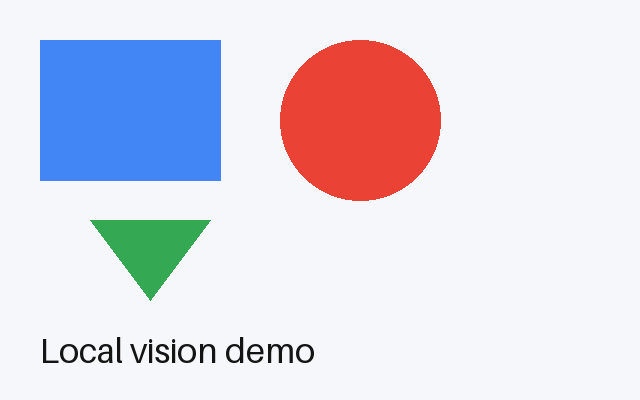

In [17]:
# Create a simple test image with shapes and text (renders inline as the cell output).
#
# Font size matters more than anything else here. PIL's default font is an ~11px bitmap,
# which a vision model cannot read reliably at this canvas size - it will hallucinate
# plausible-looking text. If the model misreads your test image, suspect the image first.

ensure_import("PIL", "Pillow")

import os
import tempfile

from PIL import Image, ImageDraw, ImageFont


def load_font(size):
    "A readable font, with fallbacks across OSes and Pillow versions."
    for path in ("/System/Library/Fonts/Supplemental/Arial.ttf",      # macOS
                 "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",   # Linux / Colab
                 "C:\\Windows\\Fonts\\arial.ttf"):                    # Windows
        try:
            return ImageFont.truetype(path, size)
        except OSError:
            continue
    try:
        return ImageFont.load_default(size=size)   # Pillow >= 10.1
    except TypeError:
        print("[warn] old Pillow: falling back to the tiny default font; OCR may fail.")
        return ImageFont.load_default()


img = Image.new("RGB", (640, 400), (245, 247, 250))
d = ImageDraw.Draw(img)
d.rectangle([40, 40, 220, 180], fill=(66, 133, 244))               # blue rectangle
d.ellipse([280, 40, 440, 200], fill=(234, 67, 53))                 # red circle
d.polygon([(150, 300), (90, 220), (210, 220)], fill=(52, 168, 83)) # green triangle
d.text((40, 330), "Local vision demo", fill=(20, 20, 20), font=load_font(34))

# Write to a temp directory, NOT the working directory: a notebook should not drop
# stray files into whatever repo you happen to have it checked out in.
IMAGE_PATH = os.path.join(tempfile.mkdtemp(prefix="llm_demo_"), "sample.png")
img.save(IMAGE_PATH)
print("Wrote", IMAGE_PATH)
img

In [18]:
# Call 1 - Ollama native REST API with an image (base64-encoded).

import base64


VISION_MODEL = require("VISION_MODEL", "pulls the vision model (top of Part 4)")
IMAGE_PATH = require("IMAGE_PATH", "creates the test image")

# Re-read the file here rather than reusing a variable from the cell above, so this cell
# stands on its own if you run it in isolation.
with open(IMAGE_PATH, "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

resp = requests.post(
    f"{OLLAMA_URL}/api/chat",
    json={
        "model": VISION_MODEL,
        "messages": [{
            "role": "user",
            "content": "Describe this image: list the shapes, their colors, and any text.",
            "images": [b64],
        }],
        "stream": False,
    },
    timeout=120,
).json()
print(resp.get("message", {}).get("content", resp))

Based on the image provided, here is a description listing the shapes, their colors, and any text:

**Shapes and Colors:**
*   **Blue Square/Rectangle:** A solid blue shape located in the upper left portion.
*   **Red Circle:** A solid red circular shape located next to the blue square.
*   **Green Triangle:** An upright green triangle (pointing downward) located below the blue square.

**Text:**
*   "Local vision demo" (Located below the green triangle).


In [19]:
# Call 2 - the same task via the OpenAI-compatible endpoint (image passed as a data URI).
#
# Note the difference in shape: Ollama's native API takes a separate "images" list, while
# the OpenAI format puts the image inline in the message content as a typed part. Same
# model, same server, two wire formats. The OpenAI one is what ports to other providers.

import base64


client = require("client", "creates the OpenAI-compatible client (Part 2)")
VISION_MODEL = require("VISION_MODEL", "pulls the vision model (top of Part 4)")
IMAGE_PATH = require("IMAGE_PATH", "creates the test image")

with open(IMAGE_PATH, "rb") as f:
    b64 = base64.b64encode(f.read()).decode()
data_uri = "data:image/png;base64," + b64

out = client.chat.completions.create(
    model=VISION_MODEL,
    messages=[{
        "role": "user",
        "content": [
            {"type": "text", "text": "What shapes and text do you see? Answer in one line."},
            {"type": "image_url", "image_url": {"url": data_uri}},
        ],
    }],
)
print(out.choices[0].message.content)

Blue square, red circle, green downward-pointing shape (or triangle), and the text "Local vision demo."


---

## Appendix - LM Studio (Run on Your Own Machine)

LM Studio is a **desktop app**, so it cannot run in Colab. Once it is running locally it exposes the
same OpenAI-compatible server, so the client code is nearly identical to the Ollama sections: a
different port and a different model id.

**On your own computer:**
1. Install LM Studio from [lmstudio.ai](https://lmstudio.ai).
2. Download a model in the app (on a 16 GB Mac, try `Qwen3.5-4B` or `Qwen3.5-9B`, and switch the runtime to **MLX**).
3. Open **Developer / Local Server** and **Start Server** (default port `1234`), or run `lms server start`.
4. Run this **locally** (not in Colab):

```python
from openai import OpenAI
client = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")
out = client.chat.completions.create(
    model="qwen3.5-4b",   # the id shown in LM Studio's server panel
    messages=[{"role": "user", "content": "Hello from LM Studio!"}],
)
print(out.choices[0].message.content)
```


---

## Recap

| Runtime / model | Size | Best for | Runs in Colab? |
|---|---|---|---|
| **llama.cpp** | - | Portable, embeddable, widest hardware | Yes |
| **Ollama** | - | Fastest start, model management | Yes |
| **Qwen3.5-4B** | ~3.4 GB | Fast text on 16 GB machines | Yes |
| **Gemma 4 E4B** | ~9.6 GB | Vision on a 16 GB Mac or a 12 GB+ GPU | Yes |
| **llava** | ~4.7 GB | Vision when you only have 8 GB of VRAM | Yes |
| **LM Studio** | - | GUI-first exploration on desktop | No (desktop app) |

**Picking a model:** match memory first (Part 0), then task. Size by the **download**, not the name: "E4B" is ~9.6 GB and a "17B active" MoE like Llama 4 Scout is really 109B of resident weights. On 16 GB stay around 4-9B (Qwen3.5-4B/9B); on a 24 GB GPU, Qwen3.6-27B is the top pick. All of these converge on the OpenAI API format, so your application code stays the same across them.

**Which API to call:** the OpenAI-compatible endpoint by default, because it keeps your code portable. Reach for a runtime's native API only when you need a control the OpenAI format has no field for, as Parts 3 and 4 do with `think` and `images`.

---

## Cleaning Up - Where the Models Live

Running out of disk is the most common thing that goes wrong a few days into experimenting with
local models. Downloads are large, nothing expires on its own, and the files are not where most
people look.

| What | Where |
|---|---|
| Ollama models | `~/.ollama/models` (macOS / Linux), `%USERPROFILE%\.ollama\models` (Windows) |
| The Part 1 GGUF | `~/.cache/huggingface` (Ollama does not manage this one) |

Two different resources are in play, and mixing them up causes confusion:

- **Disk** is what `ollama pull` consumes and `ollama rm` frees.
- **Memory** is what a model consumes once loaded. Ollama keeps a model resident for 5 minutes after the last request, then unloads it. `ollama ps` shows what is resident right now, `ollama stop` unloads it immediately, and the `keep_alive` field on an API call overrides the timeout (`"keep_alive": 0` unloads as soon as the response is done).

A full run of this notebook downloads about **17 GB**: roughly 15 GB of Ollama models plus the ~2 GB
GGUF from Part 1. The cell below reports both resources, `ollama list` for disk, `ollama ps` for
memory, plus the size of the Hugging Face cache. It is deliberately read-only: it prints the
`rm` / `stop` / `delete-cache` commands rather than running them.

In [20]:
# What this notebook left on your disk and in memory. Read-only: nothing is deleted here.

if not have("ollama"):
    print("ollama not installed; nothing to report.")
else:
    print("=== On disk (ollama list) ===")
    print(run_cmd("ollama", "list", echo=False)[1] or "(no output)")

    print("\n=== Resident in RAM/VRAM right now (ollama ps) ===")
    print(run_cmd("ollama", "ps", echo=False)[1] or "(no output)")

# The Part 1 GGUF is managed by Hugging Face, not Ollama, so report it separately.
hf_cache = os.path.expanduser("~/.cache/huggingface/hub")
if os.path.isdir(hf_cache):
    total = sum(os.path.getsize(os.path.join(root, f))
                for root, _, files in os.walk(hf_cache)
                for f in files
                if not os.path.islink(os.path.join(root, f)))
    print(f"\n=== Hugging Face cache ===\n{hf_cache}: {total / 1e9:.1f} GB")

print("""
To reclaim space (run these yourself; this cell deliberately does not):

    ollama rm gemma4:e4b       # delete a model from disk (~9.6 GB for this one)
    ollama stop gemma4:e4b     # unload from memory, keep it on disk
    huggingface-cli delete-cache   # interactive cleanup of the Part 1 GGUF
""")

=== On disk (ollama list) ===
NAME          ID              SIZE      MODIFIED           
gemma4:e4b    c6eb396dbd59    9.6 GB    About a minute ago    
qwen3.5:4b    2a654d98e6fb    3.4 GB    9 minutes ago         
qwen2.5:3b    357c53fb659c    1.9 GB    12 minutes ago

=== Resident in RAM/VRAM right now (ollama ps) ===
NAME          ID              SIZE      PROCESSOR    CONTEXT    UNTIL              
gemma4:e4b    c6eb396dbd59    3.2 GB    100% GPU     4096       4 minutes from now

=== Hugging Face cache ===
/root/.cache/huggingface/hub: 1.9 GB

To reclaim space (run these yourself; this cell deliberately does not):

    ollama rm gemma4:e4b       # delete a model from disk (~9.6 GB for this one)
    ollama stop gemma4:e4b     # unload from memory, keep it on disk
    huggingface-cli delete-cache   # interactive cleanup of the Part 1 GGUF



---
<p>Copyright &copy 2026 <a href="https://www.linkedin.com/in/scgupta">Satish Chandra Gupta</a>.</p>
<img src="https://licensebuttons.net/l/by-nc-sa/3.0/88x31.png" align="left"/> <p>&nbsp;<a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">CC BY-NC-SA 4.0 International</a> License.</p>